In [1]:
import pandas as pd
import xgboost as xgb
import shap
import joblib
import matplotlib.pyplot as plt

c:\Users\Administrator\AppData\Local\pypoetry\Cache\virtualenvs\csc133-modsim-92kyXspl-py3.13\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
model = joblib.load('../model/xgboost_scheduler_model.pkl')
df = pd.read_parquet('../dataset/df_final.parquet')

In [6]:
features = [
    'requested_processors', 'requested_time', 'queue_number', 
    'think_time', 'preceding_job_number', 'current_cpu_utilization'
]

In [7]:
X = df[features]

In [8]:
X_sample = X.sample(n=50000, random_state=42)

In [9]:
explainer = shap.TreeExplainer(model)

In [10]:
shap_values = explainer.shap_values(X_sample)

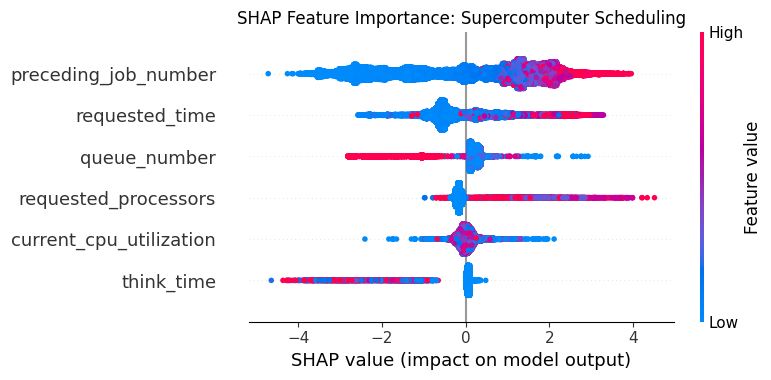

In [11]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Feature Importance: Supercomputer Scheduling")
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300)
plt.show()